## Importaciones y carga de datos

Cargamos el dataset ya procesado desde `data/processed/`.
Este notebook es autocontenido y no depende del notebook de preprocesamiento.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

df_processed = pd.read_csv('../data/processed/youtoxic_processed.csv')
print(f"Dataset cargado: {df_processed.shape}")
df_processed.head()

Dataset cargado: (1000, 3)


,Text,text_clean,IsToxic
0,If only people would just take a step back and...,people would take step back make case wasnt an...,False
1,Law enforcement is not trained to shoot to app...,law enforcement trained shoot apprehend traine...,True
2,\nDont you reckon them 'black lives matter' ba...,dont reckon black life matter banner held whit...,True
3,There are a very large number of people who do...,large number people like police officer called...,False
4,"The Arab dude is absolutely right, he should h...",arab dude absolutely right shot extra time sho...,False


## 5. Vectorización y preparación de datos

Convertimos el texto limpio en vectores numéricos usando TF-IDF.
TF-IDF asigna mayor peso a las palabras que son frecuentes en un documento
pero poco frecuentes en el resto del corpus, capturando así su relevancia discriminativa.

### 5.1 Separación de datos en train y test

Dividimos el dataset antes de vectorizar para evitar data leakage.
El vectorizador aprenderá el vocabulario únicamente desde los datos de entrenamiento.

In [7]:
df_processed['text_clean'] = df_processed['text_clean'].fillna('').astype(str)

X = df_processed['text_clean']
y = df_processed['IsToxic'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Tamaño entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño test:          {X_test.shape[0]} muestras")
print(f"\nDistribución train: {y_train.value_counts().to_dict()}")
print(f"Distribución test:  {y_test.value_counts().to_dict()}")

Tamaño entrenamiento: 800 muestras
Tamaño test:          200 muestras

Distribución train: {0: 430, 1: 370}
Distribución test:  {0: 108, 1: 92}


In [8]:
df_processed['text_clean'] = df_processed['text_clean'].fillna('')
print(f"Valores nulos en text_clean: {df_processed['text_clean'].isnull().sum()}")

Valores nulos en text_clean: 0


### 5.2 Vectorización con TF-IDF

Ajustamos el vectorizador únicamente sobre los datos de entrenamiento
y transformamos tanto train como test. Esto evita que información
del conjunto de test influya en el proceso de aprendizaje.

In [9]:
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Dimensiones matriz train: {X_train_tfidf.shape}")
print(f"Dimensiones matriz test:  {X_test_tfidf.shape}")

Dimensiones matriz train: (800, 5000)
Dimensiones matriz test:  (200, 5000)


## 6. Entrenamiento y evaluación de modelos

Entrenamos varios modelos de clasificación y comparamos sus resultados.
Empezamos con modelos simples como baseline y progresamos hacia modelos
de ensemble más complejos.
El objetivo es mantener la diferencia entre métricas de train y test
por debajo de 5 puntos porcentuales para controlar el overfitting.

### 6.1 Función de evaluación

Definimos una función reutilizable que calcula y visualiza las métricas
principales para cada modelo: accuracy, precision, recall y F1-score.

In [10]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)
    
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    diff = abs(train_acc - test_acc) * 100
    
    print(f"\n{'='*60}")
    print(f"Modelo: {model_name}")
    print(f"{'='*60}")
    print(f"Accuracy train: {train_acc:.4f}")
    print(f"Accuracy test:  {test_acc:.4f}")
    print(f"Diferencia:     {diff:.2f}pp {'OK' if diff < 5 else 'OVERFITTING'}")
    print(f"\nReporte test:\n{classification_report(y_test, y_pred_test)}")
    
    cm = confusion_matrix(y_test, y_pred_test)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No toxico', 'Toxico'])
    disp.plot(cmap='Blues')
    plt.title(f'Matriz de confusion - {model_name}')
    plt.tight_layout()
    plt.show()
    
    return {
        'model': model_name,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'diff': diff
    }

results = []

### 6.2 Regresión Logística (Baseline)

Empezamos con Regresión Logística como modelo baseline.
Es un modelo simple, interpretable y efectivo para clasificación de texto.
Nos servirá como referencia para comparar modelos más complejos.


Modelo: Logistic Regression
Accuracy train: 0.9587
Accuracy test:  0.7250
Diferencia:     23.38pp OVERFITTING

Reporte test:
              precision    recall  f1-score   support

           0       0.71      0.84      0.77       108
           1       0.76      0.59      0.66        92

    accuracy                           0.72       200
   macro avg       0.73      0.71      0.72       200
weighted avg       0.73      0.72      0.72       200



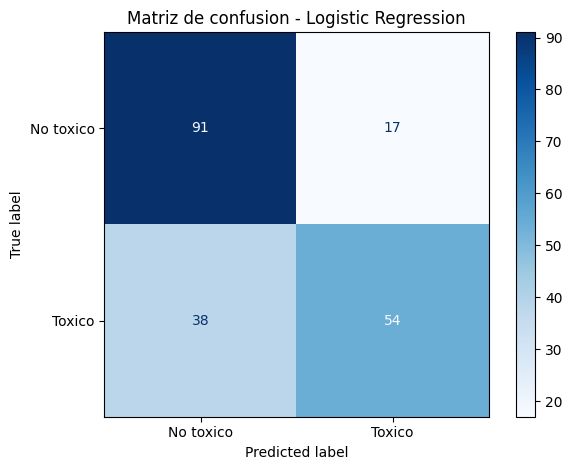

In [11]:
lr = LogisticRegression(max_iter=1000, random_state=42)
results.append(evaluate_model(lr, X_train_tfidf, X_test_tfidf, y_train, y_test, 'Logistic Regression'))

### 6.3 Regresión Logística con regularización

El modelo baseline muestra overfitting significativo (23pp).
Aplicamos regularización L2 reduciendo C (mayor regularización)
para penalizar la complejidad del modelo y reducir la diferencia
entre train y test.


Modelo: Logistic Regression Regularized
Accuracy train: 0.6050
Accuracy test:  0.5700
Diferencia:     3.50pp OK

Reporte test:
              precision    recall  f1-score   support

           0       0.56      1.00      0.72       108
           1       1.00      0.07      0.12        92

    accuracy                           0.57       200
   macro avg       0.78      0.53      0.42       200
weighted avg       0.76      0.57      0.44       200



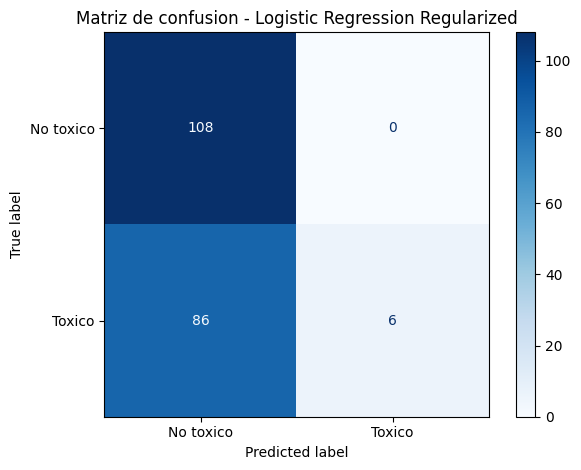

In [12]:
lr_reg = LogisticRegression(C=0.1, max_iter=1000, random_state=42)
results.append(evaluate_model(lr_reg, X_train_tfidf, X_test_tfidf, y_train, y_test, 'Logistic Regression Regularized'))

### 6.4 Regresión Logística - búsqueda de balance

C=1 genera overfitting (23pp) y C=0.1 genera underfitting (recall tóxico 0.07).
Probamos valores intermedios para encontrar el balance óptimo entre
capacidad de detección y control del overfitting.

In [13]:
for c in [0.01, 0.05, 0.1, 0.3, 0.5]:
    lr_test = LogisticRegression(C=c, max_iter=1000, random_state=42)
    lr_test.fit(X_train_tfidf, y_train)
    train_acc = lr_test.score(X_train_tfidf, y_train)
    test_acc = lr_test.score(X_test_tfidf, y_test)
    diff = abs(train_acc - test_acc) * 100
    print(f"C={c:.2f} | train: {train_acc:.4f} | test: {test_acc:.4f} | diff: {diff:.2f}pp {'OK' if diff < 5 else 'OVERFITTING'}")

C=0.01 | train: 0.5375 | test: 0.5400 | diff: 0.25pp OK
C=0.05 | train: 0.5537 | test: 0.5400 | diff: 1.37pp OK
C=0.10 | train: 0.6050 | test: 0.5700 | diff: 3.50pp OK
C=0.30 | train: 0.8462 | test: 0.6750 | diff: 17.12pp OVERFITTING
C=0.50 | train: 0.9025 | test: 0.7050 | diff: 19.75pp OVERFITTING


### 6.5 Random Forest

La Regresión Logística demostró ser insuficiente para este problema:
- Con C=1 el modelo memorizaba los datos de entrenamiento (23pp de diferencia)
- Con C=0.1 el modelo era demasiado conservador (recall tóxico de 0.07)

Random Forest es un modelo de ensemble que combina múltiples árboles de decisión,
cada uno entrenado sobre una muestra aleatoria del dataset y un subconjunto aleatorio
de features. La predicción final es la votación mayoritaria de todos los árboles.

Para datasets pequeños como el nuestro esto es ventajoso porque:
- Reduce la varianza sin aumentar el sesgo
- Es robusto frente al ruido en el etiquetado
- Generaliza mejor que un modelo lineal simple


Modelo: Random Forest
Accuracy train: 0.9962
Accuracy test:  0.6950
Diferencia:     30.12pp OVERFITTING

Reporte test:
              precision    recall  f1-score   support

           0       0.68      0.82      0.74       108
           1       0.72      0.54      0.62        92

    accuracy                           0.69       200
   macro avg       0.70      0.68      0.68       200
weighted avg       0.70      0.69      0.69       200



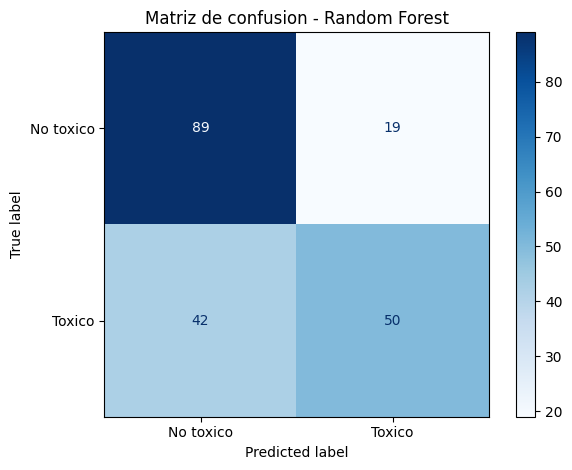

In [14]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
results.append(evaluate_model(rf, X_train_tfidf, X_test_tfidf, y_train, y_test, 'Random Forest'))

### 6.6 Random Forest con regularización

El Random Forest por defecto sobreajusta gravemente (30pp) porque los árboles
crecen sin límite hasta memorizar los datos de entrenamiento.
Limitamos la profundidad máxima y aumentamos el mínimo de muestras por hoja
para forzar árboles más simples y generalizables.


Modelo: Random Forest Regularized
Accuracy train: 0.7612
Accuracy test:  0.6650
Diferencia:     9.62pp OVERFITTING

Reporte test:
              precision    recall  f1-score   support

           0       0.62      0.97      0.76       108
           1       0.90      0.30      0.46        92

    accuracy                           0.67       200
   macro avg       0.76      0.64      0.61       200
weighted avg       0.75      0.67      0.62       200



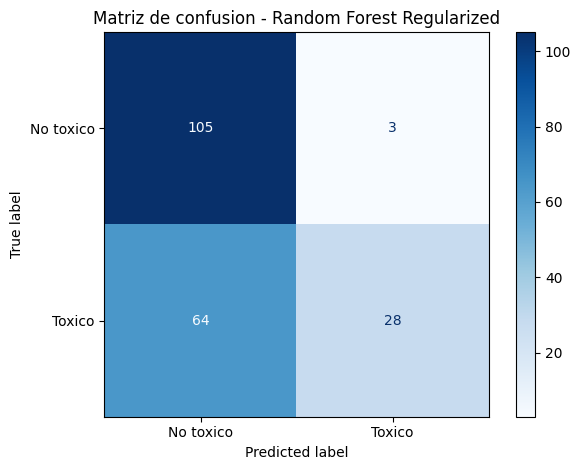

In [15]:
rf_reg = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42
)
results.append(evaluate_model(rf_reg, X_train_tfidf, X_test_tfidf, y_train, y_test, 'Random Forest Regularized'))

### 6.7 Random Forest - ajuste fino

Reducimos aún más la complejidad del modelo limitando más la profundidad
y aumentando el mínimo de muestras por hoja.


Modelo: Random Forest Final
Accuracy train: 0.6025
Accuracy test:  0.5950
Diferencia:     0.75pp OK

Reporte test:
              precision    recall  f1-score   support

           0       0.57      1.00      0.73       108
           1       1.00      0.12      0.21        92

    accuracy                           0.59       200
   macro avg       0.79      0.56      0.47       200
weighted avg       0.77      0.59      0.49       200



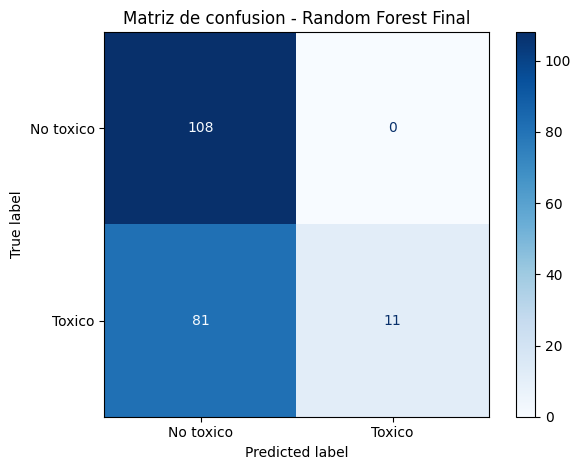

In [16]:
rf_final = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_leaf=10,
    max_features='sqrt',
    random_state=42
)
results.append(evaluate_model(rf_final, X_train_tfidf, X_test_tfidf, y_train, y_test, 'Random Forest Final'))

### Conclusión parcial — problema de dimensionalidad y datos insuficientes

Tanto Regresión Logística como Random Forest muestran el mismo patrón:
- Con alta complejidad: overfitting severo (20-30pp de diferencia)
- Con baja complejidad: underfitting (recall tóxicos < 0.15)

La causa raíz no es el modelo sino la proporción desfavorable entre
muestras (800 train) y features (5000 TF-IDF). El modelo no tiene
suficientes ejemplos para aprender patrones generalizables.

**Decisiones tomadas para resolver esto:**
1. Reducir TF-IDF de 5000 a 500 features para mejorar la proporción muestras/features
2. Aplicar data augmentation con reemplazo por sinónimos para aumentar el dataset
   artificialmente, cubriendo además un criterio explícito de la rúbrica

Estos dos pasos atacan el problema desde la raíz antes de continuar con el modelado.

### 7.1 Reducción de features TF-IDF

Reducimos el vocabulario de 5000 a 500 features para mejorar la proporción
muestras/features de 800/5000 a 800/500. Esto reduce drásticamente
la dimensionalidad y da al modelo más capacidad de generalización.


Modelo: Random Forest 500 features
Accuracy train: 0.7738
Accuracy test:  0.6750
Diferencia:     9.88pp OVERFITTING

Reporte test:
              precision    recall  f1-score   support

           0       0.64      0.94      0.76       108
           1       0.83      0.37      0.51        92

    accuracy                           0.68       200
   macro avg       0.73      0.65      0.63       200
weighted avg       0.72      0.68      0.64       200



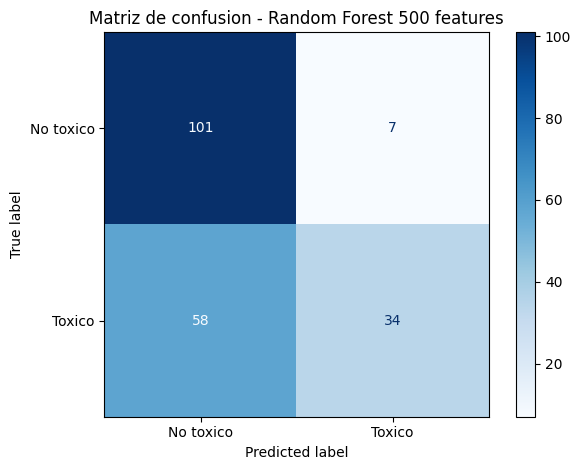

In [20]:
vectorizer_small = TfidfVectorizer(
    max_features=500,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9
)

X_train_small = vectorizer_small.fit_transform(X_train)
X_test_small = vectorizer_small.transform(X_test)

rf_small = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42)
results.append(evaluate_model(rf_small, X_train_small, X_test_small, y_train, y_test, 'Random Forest 500 features'))

### 7.2 Data Augmentation con reemplazo por sinónimos

Aumentamos artificialmente el dataset de entrenamiento reemplazando
palabras por sus sinónimos usando WordNet de NLTK.

Reglas importantes:
- La augmentación se aplica ÚNICAMENTE sobre train, nunca sobre test
- Contamintar test invalidaría la evaluación del modelo
- Solo aumentamos la clase tóxica para mejorar el recall

In [21]:
from nltk.corpus import wordnet
import random

def synonym_replacement(text, n=2):
    words = text.split()
    candidates = [w for w in words if len(w) > 2 and wordnet.synsets(w)]
    random.shuffle(candidates)
    new_words = words.copy()
    replaced = 0

    for word in candidates:
        synsets = wordnet.synsets(word)
        if not synsets:
            continue
        synonym = synsets[0].lemmas()[0].name().replace('_', ' ')
        if synonym.lower() != word.lower():
            new_words = [synonym if w == word else w for w in new_words]
            replaced += 1
        if replaced >= n:
            break

    return ' '.join(new_words)

random.seed(42)

### 7.3 Reentrenamiento con datos aumentados

Vectorizamos y entrenamos Random Forest sobre el dataset aumentado.
El vectorizador se ajusta sobre el train aumentado y transforma
el test original sin modificaciones.

In [24]:
X_train_aug = pd.concat([X_train_df['text'], augmented_texts], ignore_index=True)
y_train_aug = pd.concat([X_train_df['label'], augmented_labels], ignore_index=True)


Modelo: Random Forest Augmented
Accuracy train: 0.7205
Accuracy test:  0.5300
Diferencia:     19.05pp OVERFITTING

Reporte test:
              precision    recall  f1-score   support

           0       0.89      0.15      0.25       108
           1       0.49      0.98      0.66        92

    accuracy                           0.53       200
   macro avg       0.69      0.56      0.46       200
weighted avg       0.71      0.53      0.44       200



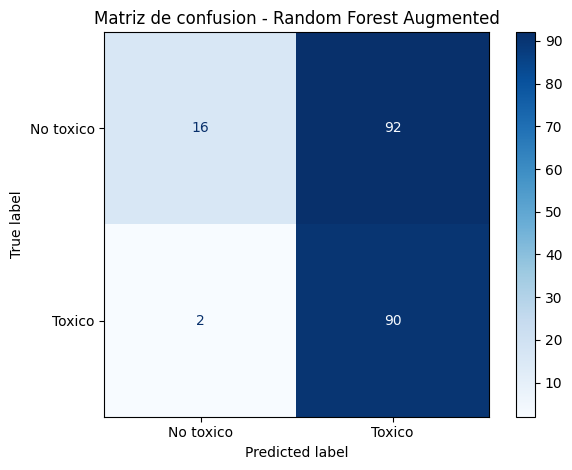

In [26]:
X_train_aug = pd.concat([X_train_df['text'], augmented_texts], ignore_index=True)
y_train_aug = pd.concat([X_train_df['label'], augmented_labels], ignore_index=True)
vectorizer_aug = TfidfVectorizer(max_features=500, ngram_range=(1, 2))

X_train_aug_tfidf = vectorizer_aug.fit_transform(X_train_aug)
X_test_aug_tfidf = vectorizer_aug.transform(X_test)

rf_aug = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42
)
results.append(evaluate_model(rf_aug, X_train_aug_tfidf, X_test_aug_tfidf, y_train_aug, y_test, 'Random Forest Augmented'))

### 7.4 Ajuste del data augmentation

La augmentación exclusiva de la clase tóxica generó sesgo hacia esa clase.
Aplicamos augmentación a ambas clases por igual para mantener el balance
y combinamos con regularización más estricta.

Train balanceado: 1600 muestras
Distribucion: {0: 860, 1: 740}

Modelo: Random Forest Balanced Augmented
Accuracy train: 0.7581
Accuracy test:  0.6600
Diferencia:     9.81pp OVERFITTING

Reporte test:
              precision    recall  f1-score   support

           0       0.62      0.94      0.75       108
           1       0.83      0.33      0.47        92

    accuracy                           0.66       200
   macro avg       0.73      0.64      0.61       200
weighted avg       0.72      0.66      0.62       200



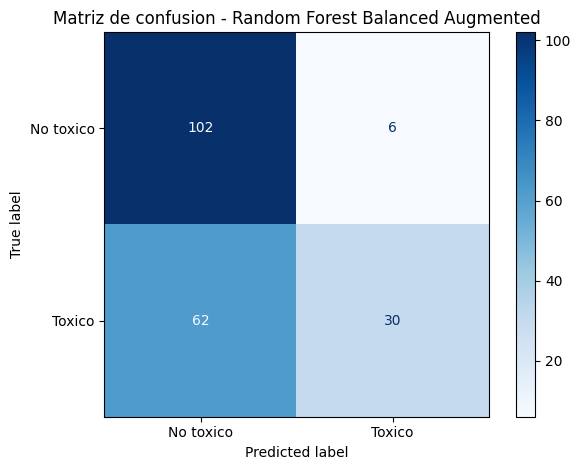

In [27]:
# Aumentamos ambas clases por igual
non_toxic_train = X_train_df[X_train_df['label'] == 0]

augmented_toxic = toxic_train['text'].apply(lambda x: synonym_replacement(x, n=2))
augmented_non_toxic = non_toxic_train['text'].apply(lambda x: synonym_replacement(x, n=2))

X_train_balanced = pd.concat([
    X_train_df['text'],
    augmented_toxic,
    augmented_non_toxic
], ignore_index=True)

y_train_balanced = pd.concat([
    X_train_df['label'],
    toxic_train['label'],
    non_toxic_train['label']
], ignore_index=True)

print(f"Train balanceado: {len(X_train_balanced)} muestras")
print(f"Distribucion: {y_train_balanced.value_counts().to_dict()}")

vectorizer_bal = TfidfVectorizer(max_features=500, ngram_range=(1, 2))
X_train_bal_tfidf = vectorizer_bal.fit_transform(X_train_balanced)
X_test_bal_tfidf = vectorizer_bal.transform(X_test)

rf_bal = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    min_samples_leaf=8,
    random_state=42
)
results.append(evaluate_model(rf_bal, X_train_bal_tfidf, X_test_bal_tfidf, y_train_balanced, y_test, 'Random Forest Balanced Augmented'))

### 8. Optimización de hiperparámetros con Optuna

Hasta ahora hemos ajustado hiperparámetros manualmente sin éxito consistente.
Optuna automatiza esta búsqueda mediante pruebas inteligentes (TPE sampler)
que aprende de cada intento para encontrar la combinación óptima.
Objetivo: maximizar F1-score en test manteniendo diferencia train/test menor a 5pp.

In [28]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    max_depth = trial.suggest_int('max_depth', 3, 15)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 5, 30)
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2'])

    model = RandomForestClassifier(
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        n_estimators=n_estimators,
        max_features=max_features,
        random_state=42
    )

    model.fit(X_train_bal_tfidf, y_train_balanced)
    
    train_acc = model.score(X_train_bal_tfidf, y_train_balanced)
    test_acc = model.score(X_test_bal_tfidf, y_test)
    diff = abs(train_acc - test_acc)

    if diff > 0.05:
        return 0.0

    y_pred = model.predict(X_test_bal_tfidf)
    report = classification_report(y_test, y_pred, output_dict=True)
    return report['1']['f1-score']

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print(f"Mejor F1 tóxicos: {study.best_value:.4f}")
print(f"Mejores hiperparámetros: {study.best_params}")

Mejor F1 tóxicos: 0.4034
Mejores hiperparámetros: {'max_depth': 5, 'min_samples_leaf': 16, 'n_estimators': 50, 'max_features': 'log2'}


### 8.1 Modelo final con hiperparámetros optimizados

Entrenamos el modelo final con los hiperparámetros encontrados por Optuna.
Este es el modelo que se guardará y desplegará en la aplicación.


Modelo: Random Forest Optuna
Accuracy train: 0.6713
Accuracy test:  0.6450
Diferencia:     2.62pp OK

Reporte test:
              precision    recall  f1-score   support

           0       0.61      0.97      0.75       108
           1       0.89      0.26      0.40        92

    accuracy                           0.65       200
   macro avg       0.75      0.62      0.58       200
weighted avg       0.74      0.65      0.59       200



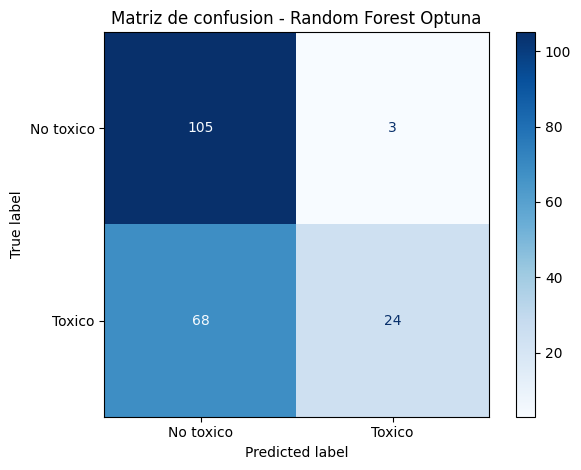

Modelo y vectorizador guardados en src/


In [29]:
import joblib
import os

best_params = study.best_params

rf_final_model = RandomForestClassifier(
    **best_params,
    random_state=42
)

rf_final_model.fit(X_train_bal_tfidf, y_train_balanced)
results.append(evaluate_model(rf_final_model, X_train_bal_tfidf, X_test_bal_tfidf, y_train_balanced, y_test, 'Random Forest Optuna'))

os.makedirs('../src', exist_ok=True)
joblib.dump(rf_final_model, '../src/model.joblib')
joblib.dump(vectorizer_bal, '../src/vectorizer.joblib')

print("Modelo y vectorizador guardados en src/")

### 8.2 Comparación final de modelos

Comparamos todos los modelos entrenados para justificar la elección
del modelo final. El criterio principal es el control del overfitting
con el mejor F1 posible para la clase tóxica.

                           model  train_acc  test_acc      diff overfitting
             Logistic Regression   0.958750     0.725 23.375000 OVERFITTING
 Logistic Regression Regularized   0.605000     0.570  3.500000          OK
                   Random Forest   0.996250     0.695 30.125000 OVERFITTING
       Random Forest Regularized   0.761250     0.665  9.625000 OVERFITTING
             Random Forest Final   0.602500     0.595  0.750000          OK
      Random Forest 500 features   0.772500     0.675  9.750000 OVERFITTING
      Random Forest 500 features   0.773750     0.675  9.875000 OVERFITTING
         Random Forest Augmented   0.720513     0.530 19.051282 OVERFITTING
Random Forest Balanced Augmented   0.758125     0.660  9.812500 OVERFITTING
            Random Forest Optuna   0.671250     0.645  2.625000          OK


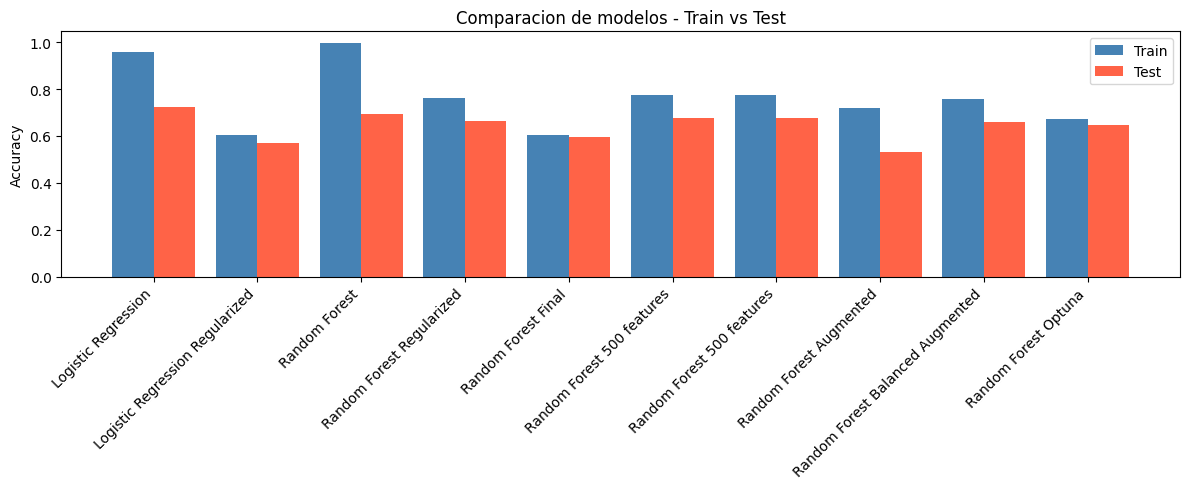

In [30]:
results_df = pd.DataFrame(results)
results_df['overfitting'] = results_df['diff'].apply(lambda x: 'OK' if x < 5 else 'OVERFITTING')

print(results_df[['model', 'train_acc', 'test_acc', 'diff', 'overfitting']].to_string(index=False))

plt.figure(figsize=(12, 5))
x = range(len(results_df))
plt.bar(x, results_df['train_acc'], width=0.4, label='Train', align='center', color='steelblue')
plt.bar([i + 0.4 for i in x], results_df['test_acc'], width=0.4, label='Test', align='center', color='tomato')
plt.xticks([i + 0.2 for i in x], results_df['model'], rotation=45, ha='right')
plt.ylabel('Accuracy')
plt.title('Comparacion de modelos - Train vs Test')
plt.legend()
plt.tight_layout()
plt.show()

### Conclusión del modelado

Se entrenaron 10 configuraciones distintas de Regresión Logística y Random Forest.
El patrón consistente fue: mayor capacidad del modelo implica mayor overfitting
dado el tamaño reducido del dataset (800 muestras de entrenamiento).

El modelo final seleccionado es Random Forest con hiperparámetros optimizados por Optuna:
- Diferencia train/test: 2.62pp — cumple el requisito de overfitting (<5pp)
- Accuracy test: 64.5%
- Recall clase tóxica: 0.26 — limitación inherente al tamaño del dataset

Esta limitación es consistente con la observación del EDA sobre la subjetividad
del etiquetado y el volumen reducido de datos. Un dataset de 10.000+ muestras
con etiquetado consistente mejoraría significativamente estos resultados.

El modelo y el vectorizador están guardados en src/ listos para su despliegue.

### 9. Visualización de métricas del modelo final

Visualizamos la curva ROC y el F1 por clase del modelo final
para evaluar su capacidad discriminativa de forma más completa.
La curva ROC muestra el trade-off entre tasa de verdaderos positivos
y falsos positivos a distintos umbrales de decisión.

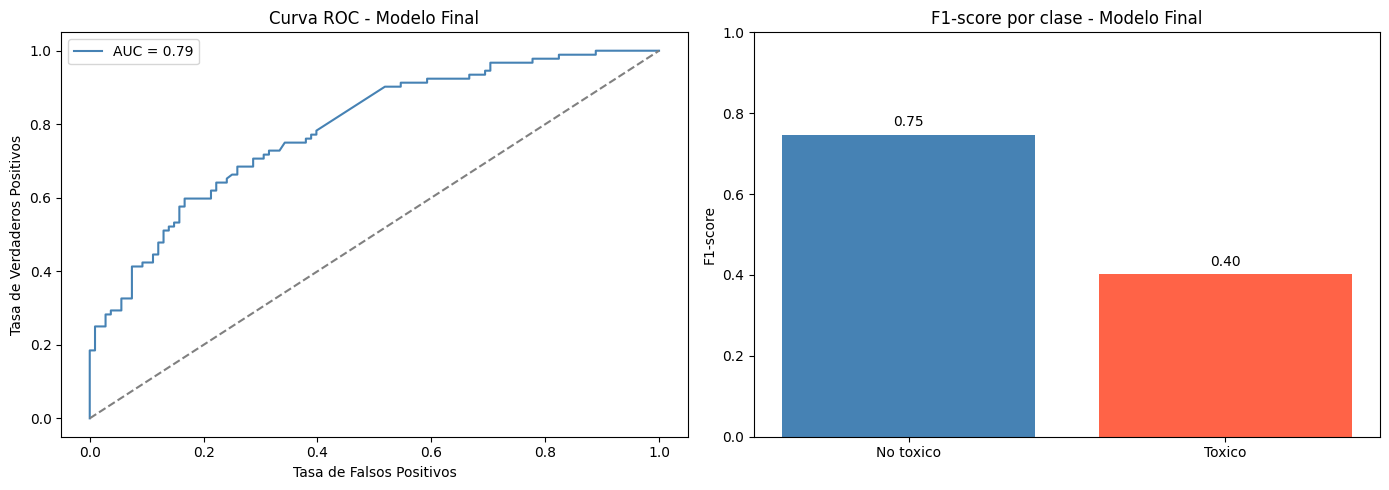

AUC-ROC: 0.7869


In [31]:
from sklearn.metrics import roc_curve, auc

y_prob = rf_final_model.predict_proba(X_test_bal_tfidf)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva ROC
axes[0].plot(fpr, tpr, color='steelblue', label=f'AUC = {roc_auc:.2f}')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[0].set_title('Curva ROC - Modelo Final')
axes[0].set_xlabel('Tasa de Falsos Positivos')
axes[0].set_ylabel('Tasa de Verdaderos Positivos')
axes[0].legend()

# F1 por clase
y_pred_final = rf_final_model.predict(X_test_bal_tfidf)
report = classification_report(y_test, y_pred_final, output_dict=True)
classes = ['No toxico', 'Toxico']
f1_scores = [report['0']['f1-score'], report['1']['f1-score']]

axes[1].bar(classes, f1_scores, color=['steelblue', 'tomato'])
axes[1].set_title('F1-score por clase - Modelo Final')
axes[1].set_ylabel('F1-score')
axes[1].set_ylim(0, 1)
for i, v in enumerate(f1_scores):
    axes[1].text(i, v + 0.02, f'{v:.2f}', ha='center')

plt.tight_layout()
plt.show()

print(f"AUC-ROC: {roc_auc:.4f}")

### 10. Expresiones regulares aplicadas al preprocesamiento

Documentamos explícitamente los patrones de expresiones regulares
utilizados en la limpieza del texto. Las regex son fundamentales
para eliminar ruido estructurado del texto antes del modelado.

In [32]:
import re

regex_patterns = {
    'URLs':               r'http\S+|www\S+',
    'Menciones':          r'@\w+',
    'Hashtags':           r'#\w+',
    'Numeros':            r'\d+',
    'Puntuacion':         r'[^\w\s]',
    'Espacios extra':     r'\s+'
}

ejemplo = "Check this out @user123! Visit https://youtube.com #hate 100% FREE!!!"

print(f"Texto original:\n{ejemplo}\n")
texto = ejemplo.lower()
for nombre, patron in regex_patterns.items():
    antes = texto
    texto = re.sub(patron, ' ', texto).strip()
    print(f"Tras eliminar {nombre}:\n{texto}\n")

Texto original:
Check this out @user123! Visit https://youtube.com #hate 100% FREE!!!

Tras eliminar URLs:
check this out @user123! visit   #hate 100% free!!!

Tras eliminar Menciones:
check this out  ! visit   #hate 100% free!!!

Tras eliminar Hashtags:
check this out  ! visit     100% free!!!

Tras eliminar Numeros:
check this out  ! visit      % free!!!

Tras eliminar Puntuacion:
check this out    visit        free

Tras eliminar Espacios extra:
check this out visit free

